<a href="https://colab.research.google.com/github/emiliomulet-commits/procuredatawhitepaper/blob/main/Copia_de_tke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from google.colab import drive, auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
import shutil
import os

# --- 1. CONEXIÓN CON DRIVE ---
drive.mount('/content/drive', force_remount=True)
auth.authenticate_user()
drive_service = build('drive', 'v3')

# --- 2. GENERACIÓN DE DATOS (10,000 registros) ---
def generar_datos_tke():
    procesos = ['Soldadura MIG/MAG/TIG', 'Plegado/Conformado (Prensas)', 'Corte Láser/Plasma', 'Pulido Abrasivo', 'Pintura y Tratamiento']
    saludes = ['Ninguna', 'Asma Bronquial/EPOC', 'Cardiopatía/Hipertensión', 'Hernia Discal Lumbar', 'Neuropatía Periférica', 'Psoriasis/Dermatitis']
    data = []

    print('🔄 Generando base de datos de 10,000 trabajadores...')
    for i in range(1, 10001):
        prov_id = random.randint(1, 50)
        proc = random.choice(procesos)
        salud = random.choices(saludes, weights=[70, 8, 6, 7, 5, 4])[0]
        fatiga = round(random.uniform(15, 98), 2)
        hrv = round(random.uniform(30, 95), 2)

        # Lógica de Aptitud según pág 24 del PDF
        aptitud = 'Apto'
        if salud != 'Ninguna':
            if (salud == 'Asma Bronquial/EPOC' and proc in ['Soldadura MIG/MAG/TIG', 'Pintura y Tratamiento']) or (salud == 'Cardiopatía/Hipertensión' and proc == 'Plegado/Conformado (Prensas)'):
                aptitud = 'No Apto'
            else:
                aptitud = 'Apto con Restricciones'

        data.append({
            'ID_Trabajador': f'TKE-{i:05d}',
            'ID_Proveedor': f'PROV-{prov_id:02d}',
            'Puesto_Trabajo': proc,
            'Estado_Salud_Previo': salud,
            'Dictamen_Medico': aptitud,
            'Nivel_Fatiga_IIoT': fatiga,
            'Salud_Cardiovascular_HRV': hrv,
            'Alerta_Riesgo': 'SÍ' if (fatiga > 75 or hrv < 45) else 'NO'
        })
    return pd.DataFrame(data)

# --- 3. GUARDAR Y PUBLICAR EN DRIVE ---
nombre_archivo = 'Base_Datos_TKE_Final.xlsx'
ruta_local = f'/content/{nombre_archivo}'

df = generar_datos_tke()
df.to_excel(ruta_local, index=False)

# Subir archivo directamente a Drive usando la API
file_metadata = {'name': nombre_archivo}
media = MediaFileUpload(ruta_local, mimetype='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')

try:
    uploaded_file = drive_service.files().create(body=file_metadata, media_body=media, fields='id, webViewLink').execute()
    file_id = uploaded_file.get('id')

    # Dar permisos de lectura a cualquiera
    drive_service.permissions().create(fileId=file_id, body={'type': 'anyone', 'role': 'reader'}).execute()

    link = uploaded_file.get('webViewLink')

    print('\n' + '⭐' * 40)
    print('¡CONSEGUIDO! TU EXCEL ESTÁ EN DRIVE:')
    print(link)
    print('⭐' * 40)
except Exception as e:
    print(f'❌ Hubo un problema al subir el archivo a Drive: {e}')
finally:
    # Limpiar el archivo localmente después de subirlo
    if os.path.exists(ruta_local):
        os.remove(ruta_local)

Mounted at /content/drive
🔄 Generando base de datos de 10,000 trabajadores...



⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
¡CONSEGUIDO! TU EXCEL ESTÁ EN DRIVE:
https://docs.google.com/spreadsheets/d/16rqjjjp1mQyHZGCAVPBDOFCxJ-UBPCLo/edit?usp=drivesdk&ouid=104280158409593951379&rtpof=true&sd=true
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐


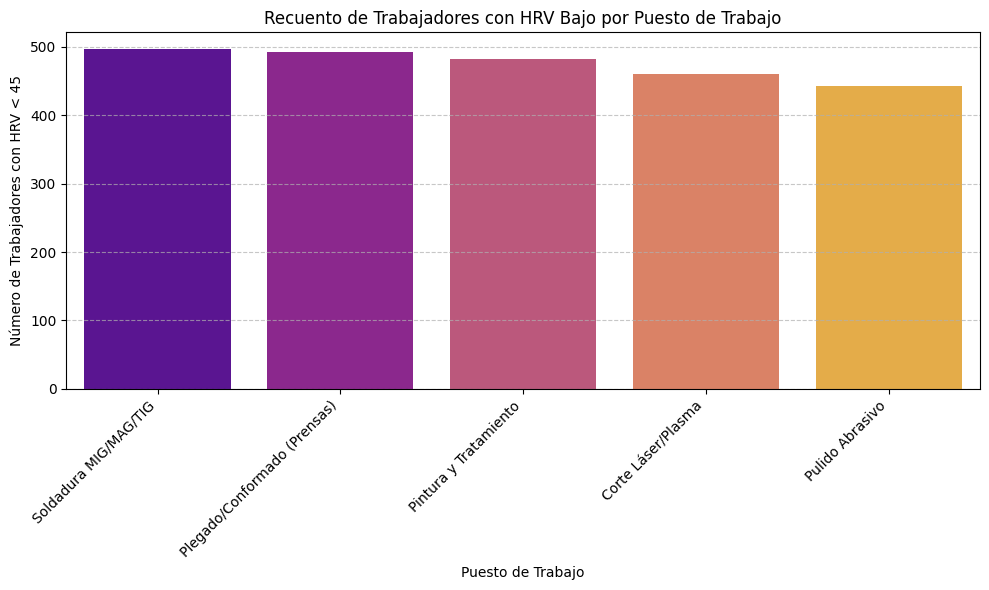

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_hrv_bajo_por_puesto.index, y=conteo_hrv_bajo_por_puesto.values, palette='plasma', hue=conteo_hrv_bajo_por_puesto.index, legend=False)
plt.title('Recuento de Trabajadores con HRV Bajo por Puesto de Trabajo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Número de Trabajadores con HRV < 45')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico de barras muestra el número de trabajadores en cada `Puesto_Trabajo` que tienen la `Salud_Cardiovascular_HRV` por debajo de 45. Es una representación visual de la tabla que vimos anteriormente y permite una identificación rápida de los puestos con mayor proporción de este factor de riesgo.

In [ ]:
trabajadores_hrv_bajo = df[df['Salud_Cardiovascular_HRV'] < 45]
conteo_hrv_bajo_por_puesto = trabajadores_hrv_bajo['Puesto_Trabajo'].value_counts()
display(conteo_hrv_bajo_por_puesto)

,count
Puesto_Trabajo,
Soldadura MIG/MAG/TIG,496
Plegado/Conformado (Prensas),492
Pintura y Tratamiento,482
Corte Láser/Plasma,460
Pulido Abrasivo,442


Esta tabla muestra el número de trabajadores en cada `Puesto_Trabajo` cuya `Salud_Cardiovascular_HRV` está por debajo del umbral de 45. Esto nos permite identificar qué puestos tienen una mayor cantidad de trabajadores con riesgo cardiovascular según este criterio.

In [ ]:
fatiga_salud_puesto = df.groupby(['Puesto_Trabajo', 'Estado_Salud_Previo'])['Nivel_Fatiga_IIoT'].mean().unstack()
display(fatiga_salud_puesto)

Estado_Salud_Previo,Asma Bronquial/EPOC,Cardiopatía/Hipertensión,Hernia Discal Lumbar,Neuropatía Periférica,Ninguna,Psoriasis/Dermatitis
Puesto_Trabajo,,,,,,
Corte Láser/Plasma,56.781988,55.928246,59.039407,57.928692,57.470681,59.652027
Pintura y Tratamiento,56.735394,58.037438,57.608844,53.167361,55.231499,56.663944
Plegado/Conformado (Prensas),56.506114,58.676306,54.926414,52.298559,56.524807,55.054429
Pulido Abrasivo,54.608924,59.474327,55.498849,59.217011,56.699217,55.691489
Soldadura MIG/MAG/TIG,57.150811,59.289650,56.055915,58.590971,56.635879,57.250444


Esta tabla muestra el nivel medio de fatiga (`Nivel_Fatiga_IIoT`) para cada combinación de `Puesto_Trabajo` y `Estado_Salud_Previo`. Puedes observar cómo la fatiga promedio varía no solo por el tipo de trabajo, sino también en función del historial de salud del trabajador.

In [ ]:
nivel_fatiga_medio = df.groupby('Puesto_Trabajo')['Nivel_Fatiga_IIoT'].mean().sort_values(ascending=False)
display(nivel_fatiga_medio)

,Nivel_Fatiga_IIoT
Puesto_Trabajo,
Corte Láser/Plasma,57.543056
Soldadura MIG/MAG/TIG,56.938487
Pulido Abrasivo,56.655711
Plegado/Conformado (Prensas),56.235853
Pintura y Tratamiento,55.689429


Esta tabla muestra el nivel medio de fatiga (`Nivel_Fatiga_IIoT`) para cada `Puesto_Trabajo`, ordenado de mayor a menor. Esto te permite identificar rápidamente qué puestos tienen, en promedio, una mayor exigencia en términos de fatiga.

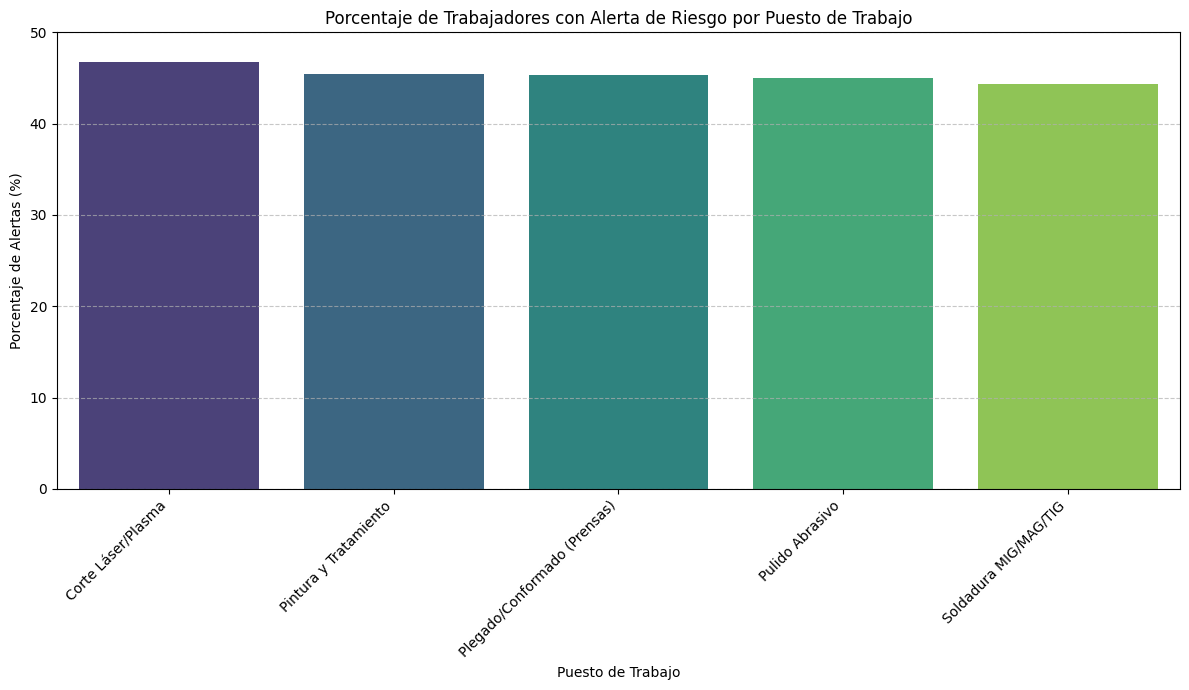

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=alerta_por_puesto.index, y='Porcentaje_Alerta_Si', data=alerta_por_puesto.sort_values(by='Porcentaje_Alerta_Si', ascending=False), palette='viridis', hue=alerta_por_puesto.index, legend=False)
plt.title('Porcentaje de Trabajadores con Alerta de Riesgo por Puesto de Trabajo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Porcentaje de Alertas (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50) # Ajustar el límite y para mejor visualización de los porcentajes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico de barras muestra el porcentaje de trabajadores con `Alerta_Riesgo = 'SÍ'` para cada `Puesto_Trabajo`. Permite identificar visualmente qué puestos tienen una mayor proporción de alertas de riesgo, confirmando la distribución que observamos numéricamente.

In [ ]:
import pandas as pd

alerta_por_puesto = df.groupby('Puesto_Trabajo')['Alerta_Riesgo'].value_counts(normalize=True).unstack(fill_value=0)

alerta_por_puesto['Porcentaje_Alerta_Si'] = alerta_por_puesto.get('SÍ', 0) * 100

display(alerta_por_puesto[['Porcentaje_Alerta_Si']].sort_values(by='Porcentaje_Alerta_Si', ascending=False))

Alerta_Riesgo,Porcentaje_Alerta_Si
Puesto_Trabajo,
Corte Láser/Plasma,46.700508
Plegado/Conformado (Prensas),45.480909
Soldadura MIG/MAG/TIG,45.341018
Pulido Abrasivo,44.961240
Pintura y Tratamiento,44.341564


Esta tabla muestra el porcentaje de trabajadores con `Alerta_Riesgo = 'SÍ'` para cada `Puesto_Trabajo`. Puedes ver qué puestos tienen una mayor proporción de alertas de riesgo en función de los criterios de fatiga y salud cardiovascular.

In [ ]:
display(df_alerta_si['Salud_Cardiovascular_HRV'])

,Salud_Cardiovascular_HRV
0,59.66
2,38.82
3,34.79
8,88.43
9,42.70
...,...
9981,91.18
9985,43.59
9992,33.52
9998,56.40


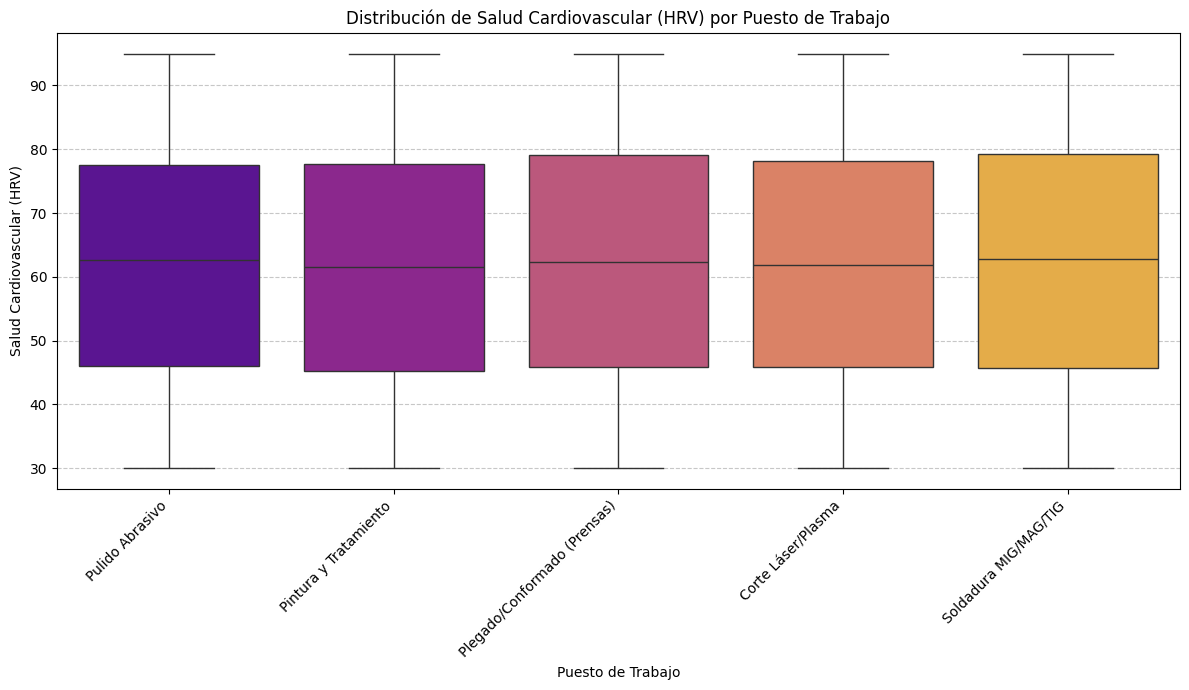

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Puesto_Trabajo', y='Salud_Cardiovascular_HRV', hue='Puesto_Trabajo', palette='plasma', legend=False)
plt.title('Distribución de Salud Cardiovascular (HRV) por Puesto de Trabajo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Salud Cardiovascular (HRV)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico de cajas y bigotes muestra la distribución del `Salud_Cardiovascular_HRV` para cada `Puesto_Trabajo`. La caja central representa el rango intercuartílico (del percentil 25 al 75), la línea dentro de la caja es la mediana, y los 'bigotes' se extienden para mostrar la dispersión de los datos, excluyendo los valores atípicos, que se muestran como puntos individuales. Este gráfico nos ayuda a comparar cómo varían los niveles de HRV entre los diferentes puestos.

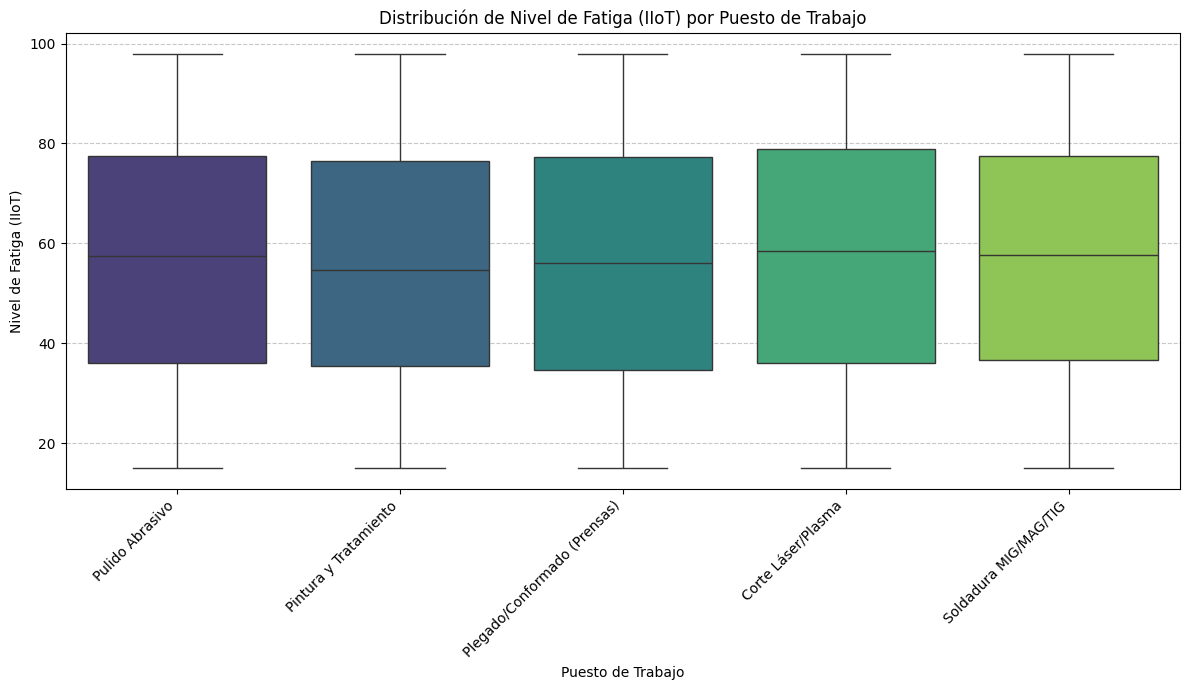

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Puesto_Trabajo', y='Nivel_Fatiga_IIoT', hue='Puesto_Trabajo', palette='viridis', legend=False)
plt.title('Distribución de Nivel de Fatiga (IIoT) por Puesto de Trabajo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Nivel de Fatiga (IIoT)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico de cajas y bigotes te permite comparar la distribución del `Nivel_Fatiga_IIoT` para cada `Puesto_Trabajo`. Cada caja representa el rango intercuartílico (del 25% al 75%), la línea en el centro es la mediana, y los 'bigotes' extienden hasta el mínimo y el máximo de los datos, excluyendo los valores atípicos (mostrados como puntos individuales).

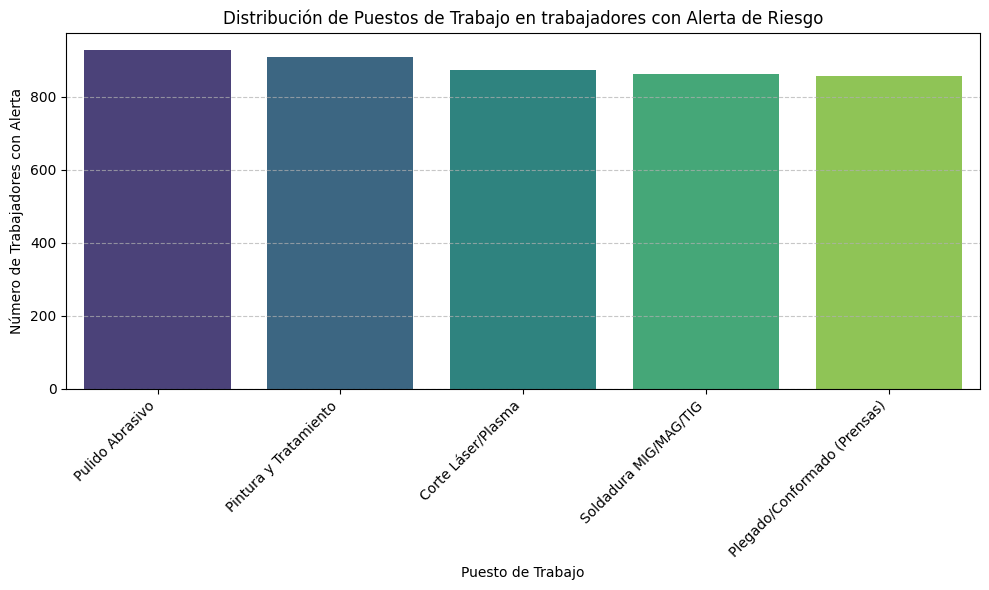

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df_alerta_si, x='Puesto_Trabajo', hue='Puesto_Trabajo', palette='viridis', order = df_alerta_si['Puesto_Trabajo'].value_counts().index, legend=False)
plt.title('Distribución de Puestos de Trabajo en trabajadores con Alerta de Riesgo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Número de Trabajadores con Alerta')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este gráfico de barras te permite ver la frecuencia de cada `Puesto_Trabajo` entre los empleados que han activado una alerta de riesgo. Podrás identificar si hay algún puesto específico con una mayor o menor proporción de alertas.

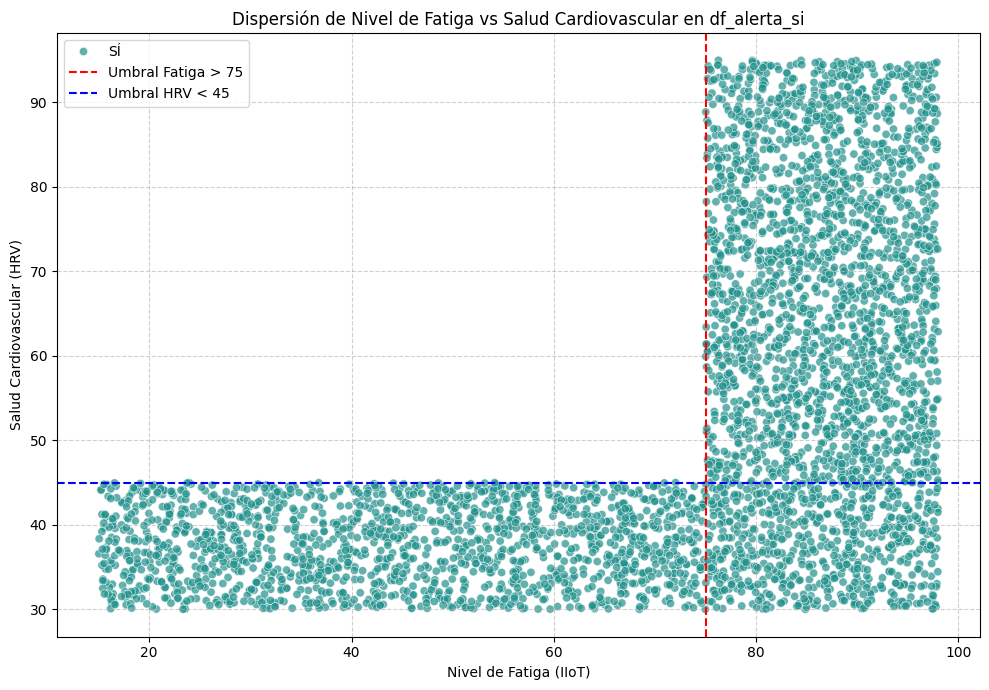

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_alerta_si, x='Nivel_Fatiga_IIoT', y='Salud_Cardiovascular_HRV', hue='Alerta_Riesgo', palette='viridis', alpha=0.7)
plt.axvline(x=75, color='red', linestyle='--', label='Umbral Fatiga > 75')
plt.axhline(y=45, color='blue', linestyle='--', label='Umbral HRV < 45')
plt.title('Dispersión de Nivel de Fatiga vs Salud Cardiovascular en df_alerta_si')
plt.xlabel('Nivel de Fatiga (IIoT)')
plt.ylabel('Salud Cardiovascular (HRV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este gráfico de dispersión visualiza la relación entre el nivel de fatiga y la salud cardiovascular para los trabajadores con alerta de riesgo. Las líneas de referencia roja y azul representan los umbrales que activan la alerta (`Nivel_Fatiga_IIoT > 75` y `Salud_Cardiovascular_HRV < 45` respectivamente). Puedes observar cómo se agrupan los puntos en relación con estos umbrales.

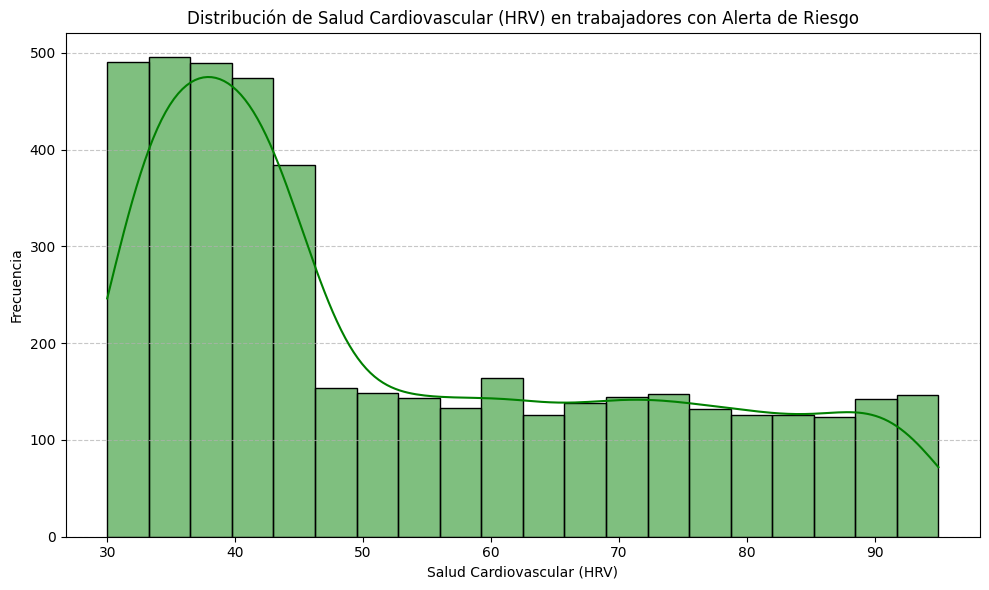

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_alerta_si['Salud_Cardiovascular_HRV'], bins=20, kde=True, color='green')
plt.title('Distribución de Salud Cardiovascular (HRV) en trabajadores con Alerta de Riesgo')
plt.xlabel('Salud Cardiovascular (HRV)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Este histograma te permitirá visualizar la distribución de la variabilidad del ritmo cardíaco entre los trabajadores que presentan una alerta de riesgo, y observar cómo se agrupan los valores en relación con el umbral de activación de la alerta (HRV < 45).

In [ ]:
print('Relación entre Estado_Salud_Previo y Dictamen_Medico en df_alerta_si:')
display(pd.crosstab(df_alerta_si['Estado_Salud_Previo'], df_alerta_si['Dictamen_Medico']))

Relación entre Estado_Salud_Previo y Dictamen_Medico en df_alerta_si:


Dictamen_Medico,Apto,Apto con Restricciones,No Apto
Estado_Salud_Previo,,,
Asma Bronquial/EPOC,0,190,132
Cardiopatía/Hipertensión,0,204,38
Hernia Discal Lumbar,0,337,0
Neuropatía Periférica,0,224,0
Ninguna,3120,0,0
Psoriasis/Dermatitis,0,184,0


Esta tabla nos permitirá ver cómo se distribuyen los dictámenes médicos para cada estado de salud previo, específicamente para los trabajadores que tienen una alerta de riesgo activa.

In [ ]:
print('Distribución de Dictamen_Medico en df_alerta_si:')
display(df_alerta_si['Dictamen_Medico'].value_counts())

Distribución de Dictamen_Medico en df_alerta_si:


,count
Dictamen_Medico,
Apto,3120
Apto con Restricciones,1139
No Apto,170


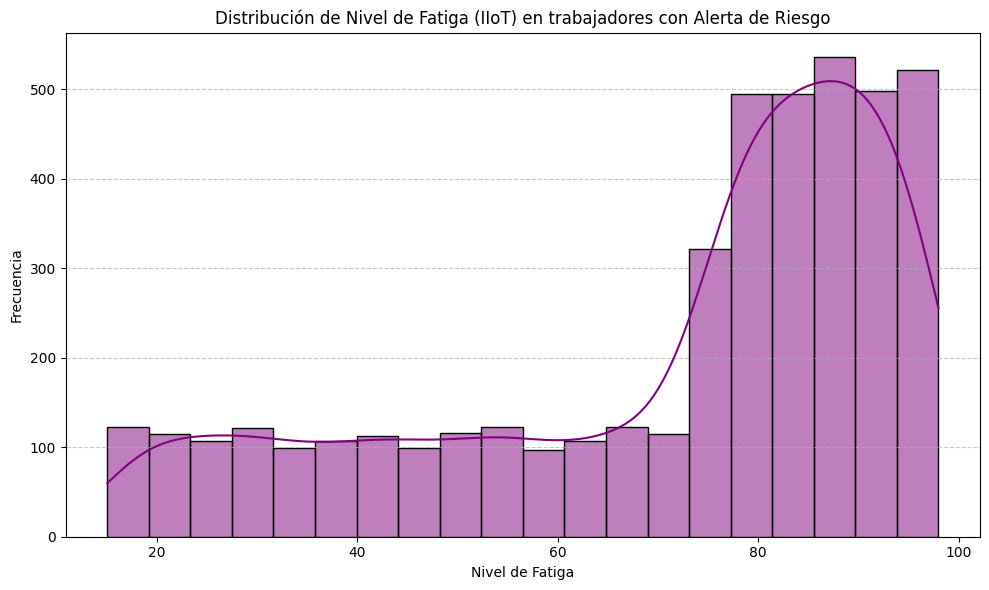

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_alerta_si['Nivel_Fatiga_IIoT'], bins=20, kde=True, color='purple')
plt.title('Distribución de Nivel de Fatiga (IIoT) en trabajadores con Alerta de Riesgo')
plt.xlabel('Nivel de Fatiga')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print('Distribución de Estado_Salud_Previo en df_alerta_si:')
display(df_alerta_si['Estado_Salud_Previo'].value_counts())

Distribución de Estado_Salud_Previo en df_alerta_si:


,count
Estado_Salud_Previo,
Ninguna,3120
Hernia Discal Lumbar,337
Asma Bronquial/EPOC,322
Cardiopatía/Hipertensión,242
Neuropatía Periférica,224
Psoriasis/Dermatitis,184


In [ ]:
print('Distribución de Alerta_Riesgo en el DataFrame completo df:')
display(df['Alerta_Riesgo'].value_counts())

Distribución de Alerta_Riesgo en el DataFrame completo df:


,count
Alerta_Riesgo,
NO,5463
SÍ,4537


In [ ]:
print('Puestos de Trabajo más comunes en df_alerta_si:')
display(df_alerta_si['Puesto_Trabajo'].value_counts())

Puestos de Trabajo más comunes en df_alerta_si:


,count
Puesto_Trabajo,
Pulido Abrasivo,928
Pintura y Tratamiento,908
Corte Láser/Plasma,873
Soldadura MIG/MAG/TIG,863
Plegado/Conformado (Prensas),857


In [ ]:
df_alerta_si = df[df['Alerta_Riesgo'] == 'SÍ']
print(f'Número de trabajadores con Alerta de Riesgo = SÍ: {len(df_alerta_si)} de {len(df)}.')
display(df_alerta_si.head())

Número de trabajadores con Alerta de Riesgo = SÍ: 4537 de 10000.


,ID_Trabajador,ID_Proveedor,Puesto_Trabajo,Estado_Salud_Previo,Dictamen_Medico,Nivel_Fatiga_IIoT,Salud_Cardiovascular_HRV,Alerta_Riesgo
0,TKE-00001,PROV-09,Pulido Abrasivo,Ninguna,Apto,80.95,37.85,SÍ
2,TKE-00003,PROV-14,Pintura y Tratamiento,Ninguna,Apto,38.66,41.07,SÍ
3,TKE-00004,PROV-15,Plegado/Conformado (Prensas),Ninguna,Apto,52.68,30.75,SÍ
4,TKE-00005,PROV-14,Corte Láser/Plasma,Ninguna,Apto,90.25,65.99,SÍ
5,TKE-00006,PROV-12,Pintura y Tratamiento,Ninguna,Apto,85.84,54.97,SÍ


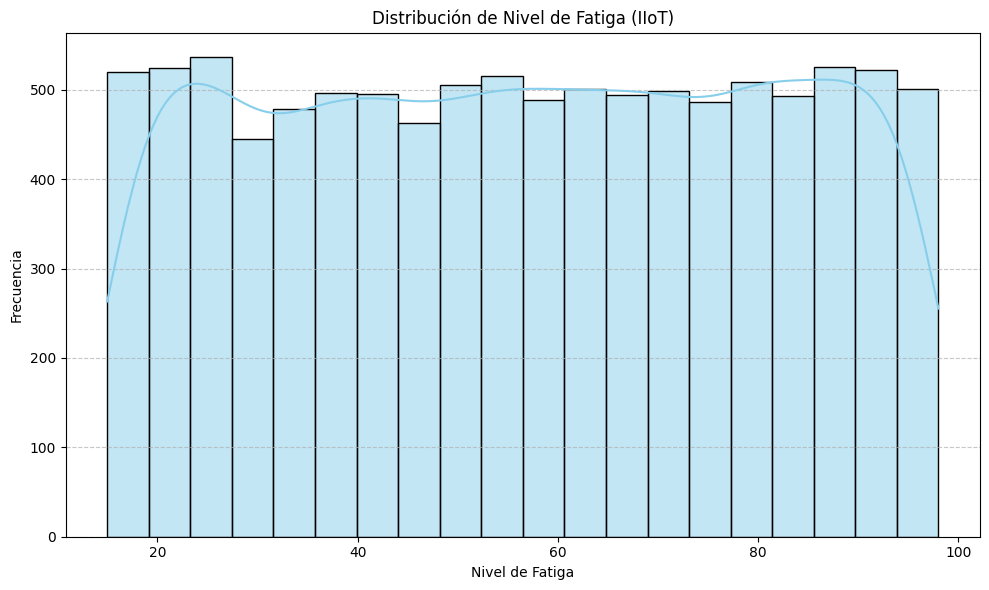

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Nivel_Fatiga_IIoT'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Nivel de Fatiga (IIoT)')
plt.xlabel('Nivel de Fatiga')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

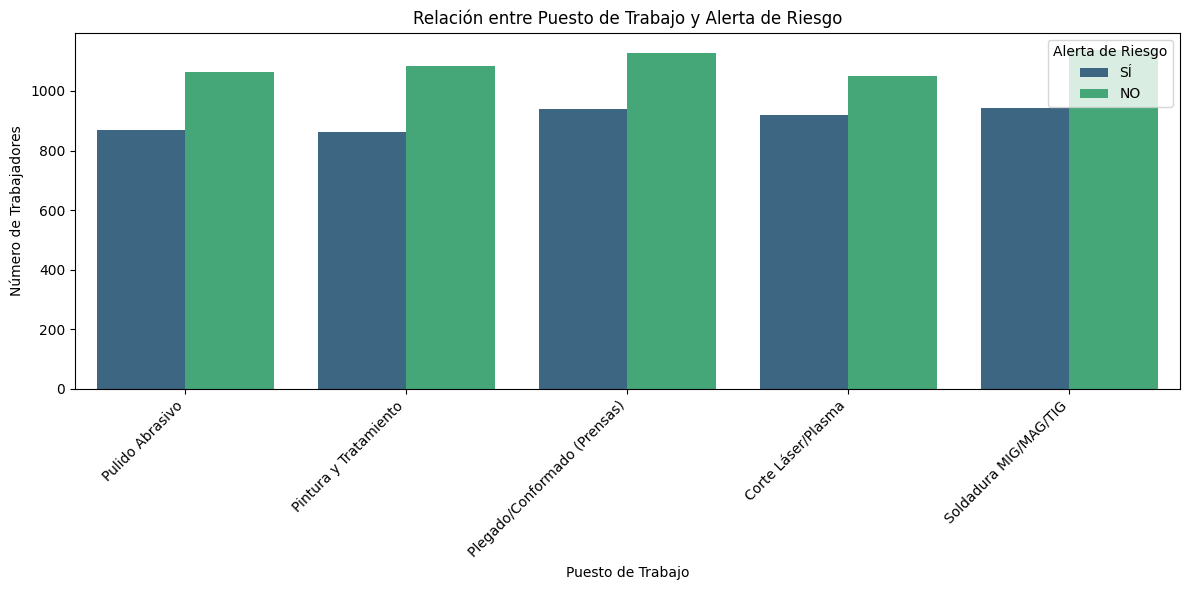

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Puesto_Trabajo', hue='Alerta_Riesgo', palette='viridis')
plt.title('Relación entre Puesto de Trabajo y Alerta de Riesgo')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Número de Trabajadores')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Alerta de Riesgo')
plt.tight_layout()
plt.show()

In [ ]:
display(df.describe())

,Nivel_Fatiga_IIoT,Salud_Cardiovascular_HRV
count,10000.000000,10000.000000
mean,56.614678,62.178263
std,24.153377,18.788923
min,15.000000,30.000000
25%,35.720000,45.747500
50%,56.670000,62.295000
75%,77.720000,78.480000
max,98.000000,95.000000


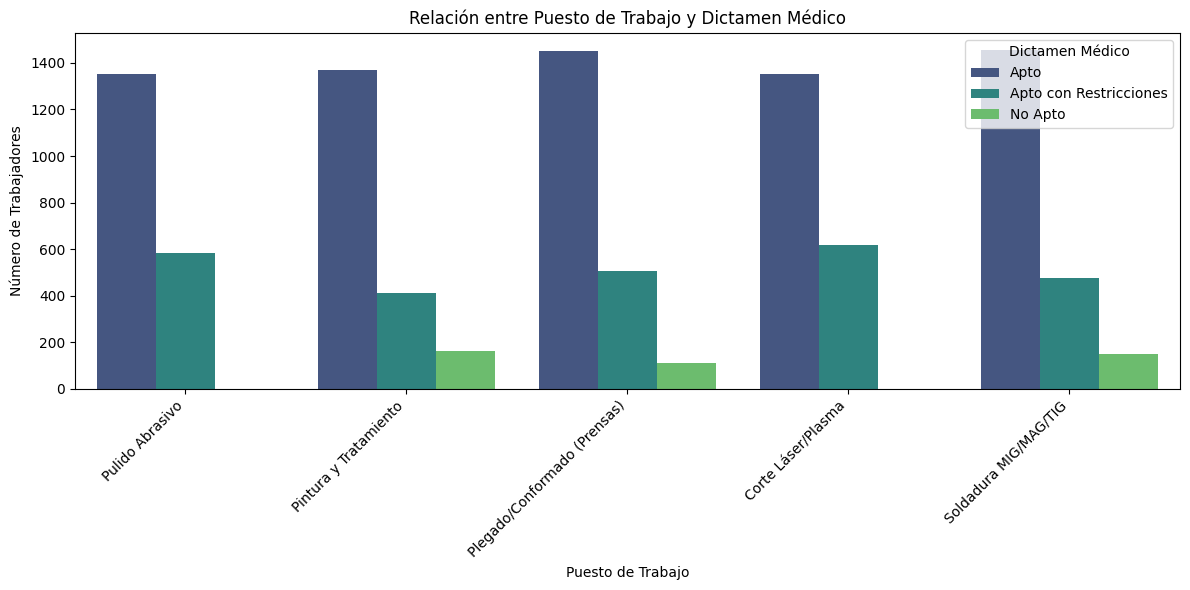

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Puesto_Trabajo', hue='Dictamen_Medico', palette='viridis')
plt.title('Relación entre Puesto de Trabajo y Dictamen Médico')
plt.xlabel('Puesto de Trabajo')
plt.ylabel('Número de Trabajadores')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dictamen Médico')
plt.tight_layout()
plt.show()

In [ ]:
print('Información general del DataFrame df:')
df.info()

Información general del DataFrame df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Trabajador             10000 non-null  object 
 1   ID_Proveedor              10000 non-null  object 
 2   Puesto_Trabajo            10000 non-null  object 
 3   Estado_Salud_Previo       10000 non-null  object 
 4   Dictamen_Medico           10000 non-null  object 
 5   Nivel_Fatiga_IIoT         10000 non-null  float64
 6   Salud_Cardiovascular_HRV  10000 non-null  float64
 7   Alerta_Riesgo             10000 non-null  object 
dtypes: float64(2), object(6)
memory usage: 625.1+ KB


In [ ]:
print('\nEstadísticas descriptivas del DataFrame df:')
display(df.describe(include='all'))


Estadísticas descriptivas del DataFrame df:


,ID_Trabajador,ID_Proveedor,Puesto_Trabajo,Estado_Salud_Previo,Dictamen_Medico,Nivel_Fatiga_IIoT,Salud_Cardiovascular_HRV,Alerta_Riesgo
count,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000
unique,10000,50,5,6,3,NaN,NaN,2
top,TKE-09984,PROV-43,Soldadura MIG/MAG/TIG,Ninguna,Apto,NaN,NaN,NO
freq,1,250,2082,6978,6978,NaN,NaN,5463
mean,NaN,NaN,NaN,NaN,NaN,56.614678,62.178263,NaN
std,NaN,NaN,NaN,NaN,NaN,24.153377,18.788923,NaN
min,NaN,NaN,NaN,NaN,NaN,15.000000,30.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,35.720000,45.747500,NaN
50%,NaN,NaN,NaN,NaN,NaN,56.670000,62.295000,NaN
75%,NaN,NaN,NaN,NaN,NaN,77.720000,78.480000,NaN
